# 13 — Instruction Fine-Tuning

**Lecture goal:** teach our pretrained GPT-2 to follow open-ended natural-language instructions and produce free-form, helpful responses — the fine-tuning paradigm behind chat-style assistants — by training on consistently-formatted (instruction, response) pairs with careful loss masking.

## How this differs from classification fine-tuning

Notebook 12 adapted the model to choose among a small, fixed set of labels (`spam`/`ham`), by replacing its output head entirely. **Instruction fine-tuning is mechanically simpler in one respect and more demanding in another:**

- Simpler: there's no architecture change at all. The model still does exactly what it always did — predict the next token — so `out_head` stays exactly as pretrained, still producing a distribution over all 50,257 vocabulary tokens.
- More demanding: rather than learning one narrow decision at a single position, the model needs to shift its general *behavior* — learning the pattern "when the input looks like an instruction, generate a helpful, on-topic response" — across every position of the response it generates. That broader shift benefits from adapting more of the network than the "just the last block" strategy from notebook 12.

We train this using nothing new mechanically: it's still the exact same next-token cross-entropy objective from notebook 10. What changes is *what data we show the model, how it's formatted, and which parts of each example we actually compute loss on.*

## The dataset

We use a small (1,100-example) public instruction dataset from the companion repository of the book this project follows (Sebastian Raschka's *Build a Large Language Model From Scratch*). Each entry has an `instruction`, an optional `input` (extra context/data the instruction refers to), and the target `output`.

In [1]:
import json
import urllib.request

url = "https://raw.githubusercontent.com/rasbt/LLMs-from-scratch/main/ch07/01_main-chapter-code/instruction-data.json"
request = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
data = json.loads(urllib.request.urlopen(request, timeout=30).read())

print("Number of examples:", len(data))
print(data[0])
print(data[1])

Number of examples: 1100
{'instruction': 'Evaluate the following phrase by transforming it into the spelling given.', 'input': 'freind --> friend', 'output': 'The spelling of the given phrase "freind" is incorrect, the correct spelling is "friend".'}
{'instruction': 'Edit the following sentence for grammar.', 'input': 'He go to the park every day.', 'output': 'He goes to the park every day.'}


## Formatting: the Alpaca prompt template

The model needs to see a **consistent, recognizable format** so it can learn "this pattern of text means: now generate a response." We use the widely-used Alpaca-style template. Note the `### Input:` section only appears when an example actually has one.

In [2]:
ALPACA_INSTRUCTION_TEMPLATE = (
    "Below is an instruction that describes a task. "
    "Write a response that appropriately completes the request.\n\n"
    "### Instruction:\n{instruction}"
)


def format_input(entry):
    text = ALPACA_INSTRUCTION_TEMPLATE.format(instruction=entry["instruction"])
    if entry.get("input"):
        text += f"\n\n### Input:\n{entry['input']}"
    return text


example_prompt = format_input(data[0]) + "\n\n### Response:\n"
print(example_prompt)
print("---")
print("Target output:", data[0]["output"])

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Evaluate the following phrase by transforming it into the spelling given.

### Input:
freind --> friend

### Response:

---
Target output: The spelling of the given phrase "freind" is incorrect, the correct spelling is "friend".


During training, we concatenate the formatted prompt *and* the target output into one string, and train on the whole thing with our usual next-token objective — but, critically, we'll only count loss on the **response** portion (details below). At actual generation time later, we'll feed the model exactly this same prompt format up through `"### Response:\n"` and let it generate what comes next.

## Splitting the data

In [3]:
n = len(data)
train_data = data[: int(0.85 * n)]
val_data = data[int(0.85 * n): int(0.95 * n)]
test_data = data[int(0.95 * n):]

print("train:", len(train_data), " val:", len(val_data), " test:", len(test_data))

train: 935  val: 110  test: 55


## Building the dataset: variable lengths and loss masking

Unlike the SMS messages in notebook 12 (all padded to one global fixed length), instruction/response pairs here vary quite a bit in length. We'll instead pad **dynamically, per batch** — every batch is padded only to the length of its own longest example, which wastes less computation on unnecessary padding compared to padding everything to one dataset-wide maximum.

We also need to be careful about *what the loss should and shouldn't cover*:

1. **Don't train the model to predict the prompt.** The instruction and input are *given* context, not something the model should learn to generate — we only want it to learn to produce good *responses*. We mask out (set to `-100`, PyTorch's built-in "ignore this position" value for `F.cross_entropy`) every target position that falls within the prompt.
2. **Don't let padding dominate the loss**, but **do** keep the very first padding token's loss active. That first pad token is standing in for `<|endoftext|>` — the signal that tells the model "the response is complete, stop here." If we masked that out too, the model would never learn *when* to stop generating.

Let's build this step by step.

In [4]:
import torch
import tiktoken
from torch.utils.data import Dataset, DataLoader

tokenizer = tiktoken.get_encoding("gpt2")
PAD_TOKEN_ID = 50256
IGNORE_INDEX = -100


class InstructionDataset(Dataset):
    def __init__(self, data, tokenizer):
        self.encoded_texts = []
        self.response_start_idx = []
        for entry in data:
            prompt = format_input(entry) + "\n\n### Response:\n"
            full_text = prompt + entry["output"]
            self.encoded_texts.append(tokenizer.encode(full_text))
            self.response_start_idx.append(len(tokenizer.encode(prompt)))

    def __len__(self):
        return len(self.encoded_texts)

    def __getitem__(self, idx):
        return self.encoded_texts[idx], self.response_start_idx[idx]

`response_start_idx` records where the response begins in each tokenized example — exactly what we need to know which positions to mask. The actual padding, shifting (input vs. target), and masking all happen in a **custom collate function**: the piece of code a `DataLoader` calls to combine a list of individual examples into one padded batch tensor.

In [5]:
def custom_collate_fn(batch, pad_token_id=PAD_TOKEN_ID, ignore_index=IGNORE_INDEX):
    batch_max_len = max(len(ids) for ids, _ in batch)

    input_list, target_list = [], []
    for ids, response_start in batch:
        # +1 so we have one extra pad token available to build a same-length shifted target.
        padded = ids + [pad_token_id] * (batch_max_len - len(ids) + 1)

        input_ids = torch.tensor(padded[:-1])   # everything except the last token
        target_ids = torch.tensor(padded[1:])   # everything except the first token (shifted by one)

        # Mask the prompt: don't train the model to predict the instruction itself.
        target_ids[: response_start - 1] = ignore_index

        # Mask padding, but keep the first pad token's loss active (teaches the model to stop).
        pad_positions = (target_ids == pad_token_id).nonzero().squeeze(-1)
        if len(pad_positions) > 1:
            target_ids[pad_positions[1:]] = ignore_index

        input_list.append(input_ids)
        target_list.append(target_ids)

    return torch.stack(input_list), torch.stack(target_list)

Let's see this concretely on a tiny toy batch before trusting it with real data — printing `-100` markers makes the masking easy to verify by eye.

In [6]:
toy_batch = [
    ([10, 11, 12, 13, 14], 3),  # a 5-token example; response starts at index 3
    ([20, 21, 22], 2),          # a shorter, 3-token example; response starts at index 2
]

toy_inputs, toy_targets = custom_collate_fn(toy_batch)
print("Inputs:\n", toy_inputs)
print("Targets (-100 = ignored by the loss):\n", toy_targets)

Inputs:
 tensor([[   10,    11,    12,    13,    14],
        [   20,    21,    22, 50256, 50256]])
Targets (-100 = ignored by the loss):
 tensor([[ -100,  -100,    13,    14, 50256],
        [ -100,    22, 50256,  -100,  -100]])


In row 2 (the shorter example), notice the pattern: prompt positions and all-but-one of the padding positions became `-100`, while the real response token and exactly one trailing pad token kept their real target IDs — exactly the masking behavior we described above.

Now the real `DataLoader`s.

In [7]:
train_dataset = InstructionDataset(train_data, tokenizer)
val_dataset = InstructionDataset(val_data, tokenizer)
test_dataset = InstructionDataset(test_data, tokenizer)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, drop_last=True, collate_fn=custom_collate_fn)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False, collate_fn=custom_collate_fn)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False, collate_fn=custom_collate_fn)

print("Batches — train:", len(train_loader), " val:", len(val_loader), " test:", len(test_loader))
sample_inputs, sample_targets = next(iter(train_loader))
print("Example batch shape:", sample_inputs.shape)

Batches — train: 116  val: 14  test: 7
Example batch shape: torch.Size([8, 65])


## Loading the pretrained model (same as notebooks 11/12)

No architecture changes this time — `out_head` stays exactly as pretrained.

In [8]:
import torch.nn as nn
from transformers import GPT2Model


class MultiHeadAttention(nn.Module):
    def __init__(self, d_in, d_out, context_length, dropout, num_heads, qkv_bias=False):
        super().__init__()
        assert d_out % num_heads == 0
        self.d_out = d_out
        self.num_heads = num_heads
        self.head_dim = d_out // num_heads
        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.out_proj = nn.Linear(d_out, d_out)
        self.dropout = nn.Dropout(dropout)
        self.register_buffer("mask", torch.triu(torch.ones(context_length, context_length), diagonal=1))

    def forward(self, x):
        batch_size, num_tokens, d_in = x.shape
        queries = self.W_query(x).view(batch_size, num_tokens, self.num_heads, self.head_dim).transpose(1, 2)
        keys = self.W_key(x).view(batch_size, num_tokens, self.num_heads, self.head_dim).transpose(1, 2)
        values = self.W_value(x).view(batch_size, num_tokens, self.num_heads, self.head_dim).transpose(1, 2)
        attention_scores = queries @ keys.transpose(2, 3)
        attention_scores.masked_fill_(self.mask.bool()[:num_tokens, :num_tokens], -torch.inf)
        attention_weights = torch.softmax(attention_scores / self.head_dim ** 0.5, dim=-1)
        attention_weights = self.dropout(attention_weights)
        context_vectors = (attention_weights @ values).transpose(1, 2)
        context_vectors = context_vectors.contiguous().view(batch_size, num_tokens, self.d_out)
        return self.out_proj(context_vectors)


class LayerNorm(nn.Module):
    def __init__(self, embedding_dim, eps=1e-5):
        super().__init__()
        self.eps = eps
        self.scale = nn.Parameter(torch.ones(embedding_dim))
        self.shift = nn.Parameter(torch.zeros(embedding_dim))

    def forward(self, x):
        mean = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, keepdim=True, unbiased=False)
        normalized = (x - mean) / torch.sqrt(var + self.eps)
        return self.scale * normalized + self.shift


class FeedForward(nn.Module):
    def __init__(self, embedding_dim):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(embedding_dim, 4 * embedding_dim), nn.GELU(), nn.Linear(4 * embedding_dim, embedding_dim)
        )

    def forward(self, x):
        return self.layers(x)


class TransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.attention = MultiHeadAttention(
            d_in=cfg["embedding_dim"], d_out=cfg["embedding_dim"], context_length=cfg["context_length"],
            dropout=cfg["dropout_rate"], num_heads=cfg["num_heads"], qkv_bias=cfg["qkv_bias"],
        )
        self.feed_forward = FeedForward(cfg["embedding_dim"])
        self.norm1 = LayerNorm(cfg["embedding_dim"])
        self.norm2 = LayerNorm(cfg["embedding_dim"])
        self.dropout = nn.Dropout(cfg["dropout_rate"])

    def forward(self, x):
        shortcut = x
        x = self.norm1(x)
        x = self.attention(x)
        x = self.dropout(x)
        x = x + shortcut
        shortcut = x
        x = self.norm2(x)
        x = self.feed_forward(x)
        x = self.dropout(x)
        x = x + shortcut
        return x


class GPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.token_embedding = nn.Embedding(cfg["vocab_size"], cfg["embedding_dim"])
        self.position_embedding = nn.Embedding(cfg["context_length"], cfg["embedding_dim"])
        self.dropout = nn.Dropout(cfg["dropout_rate"])
        self.transformer_blocks = nn.Sequential(*[TransformerBlock(cfg) for _ in range(cfg["num_layers"])])
        self.final_norm = LayerNorm(cfg["embedding_dim"])
        self.out_head = nn.Linear(cfg["embedding_dim"], cfg["vocab_size"], bias=False)

    def forward(self, token_ids):
        batch_size, num_tokens = token_ids.shape
        token_embeds = self.token_embedding(token_ids)
        positions = torch.arange(num_tokens, device=token_ids.device)
        pos_embeds = self.position_embedding(positions)
        x = self.dropout(token_embeds + pos_embeds)
        x = self.transformer_blocks(x)
        x = self.final_norm(x)
        return self.out_head(x)


GPT_CONFIG_124M = {
    "vocab_size": 50257, "context_length": 1024, "embedding_dim": 768,
    "num_heads": 12, "num_layers": 12, "dropout_rate": 0.0, "qkv_bias": True,
}


def assign(target_param, source_tensor, name=""):
    if target_param.shape != source_tensor.shape:
        raise ValueError(f"Shape mismatch for {name}: {target_param.shape} vs {source_tensor.shape}")
    return nn.Parameter(source_tensor.clone().detach())


hf_model = GPT2Model.from_pretrained("gpt2")
hf_state_dict = hf_model.state_dict()
model = GPTModel(GPT_CONFIG_124M)

model.token_embedding.weight = assign(model.token_embedding.weight, hf_state_dict["wte.weight"], "wte")
model.position_embedding.weight = assign(model.position_embedding.weight, hf_state_dict["wpe.weight"], "wpe")

for b in range(GPT_CONFIG_124M["num_layers"]):
    prefix = f"h.{b}."
    block = model.transformer_blocks[b]
    q_w, k_w, v_w = hf_state_dict[prefix + "attn.c_attn.weight"].chunk(3, dim=-1)
    q_b, k_b, v_b = hf_state_dict[prefix + "attn.c_attn.bias"].chunk(3, dim=-1)
    block.attention.W_query.weight = assign(block.attention.W_query.weight, q_w.T, "W_query.weight")
    block.attention.W_key.weight = assign(block.attention.W_key.weight, k_w.T, "W_key.weight")
    block.attention.W_value.weight = assign(block.attention.W_value.weight, v_w.T, "W_value.weight")
    block.attention.W_query.bias = assign(block.attention.W_query.bias, q_b, "W_query.bias")
    block.attention.W_key.bias = assign(block.attention.W_key.bias, k_b, "W_key.bias")
    block.attention.W_value.bias = assign(block.attention.W_value.bias, v_b, "W_value.bias")
    block.attention.out_proj.weight = assign(block.attention.out_proj.weight, hf_state_dict[prefix + "attn.c_proj.weight"].T, "out_proj.weight")
    block.attention.out_proj.bias = assign(block.attention.out_proj.bias, hf_state_dict[prefix + "attn.c_proj.bias"], "out_proj.bias")
    block.feed_forward.layers[0].weight = assign(block.feed_forward.layers[0].weight, hf_state_dict[prefix + "mlp.c_fc.weight"].T, "ff.0.weight")
    block.feed_forward.layers[0].bias = assign(block.feed_forward.layers[0].bias, hf_state_dict[prefix + "mlp.c_fc.bias"], "ff.0.bias")
    block.feed_forward.layers[2].weight = assign(block.feed_forward.layers[2].weight, hf_state_dict[prefix + "mlp.c_proj.weight"].T, "ff.2.weight")
    block.feed_forward.layers[2].bias = assign(block.feed_forward.layers[2].bias, hf_state_dict[prefix + "mlp.c_proj.bias"], "ff.2.bias")
    block.norm1.scale = assign(block.norm1.scale, hf_state_dict[prefix + "ln_1.weight"], "norm1.scale")
    block.norm1.shift = assign(block.norm1.shift, hf_state_dict[prefix + "ln_1.bias"], "norm1.shift")
    block.norm2.scale = assign(block.norm2.scale, hf_state_dict[prefix + "ln_2.weight"], "norm2.scale")
    block.norm2.shift = assign(block.norm2.shift, hf_state_dict[prefix + "ln_2.bias"], "norm2.shift")

model.final_norm.scale = assign(model.final_norm.scale, hf_state_dict["ln_f.weight"], "final_norm.scale")
model.final_norm.shift = assign(model.final_norm.shift, hf_state_dict["ln_f.bias"], "final_norm.shift")
model.out_head.weight = assign(model.out_head.weight, hf_state_dict["wte.weight"], "out_head.weight (tied)")

print("Pretrained GPT-2 loaded.")

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Pretrained GPT-2 loaded.


## Fine-tuning the whole model this time

In notebook 12, freezing everything except the last block, final norm, and (new) output head was enough, because the task was narrow: summarize one message into one of two buckets. Here, we want to shift *how the model writes*, broadly — every layer's representations plausibly need at least some adjustment. So this time, every parameter stays trainable (the default — we simply don't freeze anything).

This is more expensive per step than notebook 12's mostly-frozen approach, which is exactly why our dataset here is small (~935 training examples) and we'll only run a modest number of epochs.

In [9]:
import torch.nn.functional as F


def calc_loss_batch(input_batch, target_batch, model):
    logits = model(input_batch)
    loss = F.cross_entropy(logits.flatten(0, 1), target_batch.flatten(), ignore_index=IGNORE_INDEX)
    return loss


def calc_loss_loader(data_loader, model, num_batches=None):
    total_loss = 0.0
    num_batches = len(data_loader) if num_batches is None else min(num_batches, len(data_loader))
    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i >= num_batches:
            break
        with torch.no_grad():
            loss = calc_loss_batch(input_batch, target_batch, model)
        total_loss += loss.item()
    return total_loss / num_batches

## The training loop

Structurally identical to notebook 10's `train_model_simple`: the `zero_grad` / `backward` / `step` core, periodic loss tracking, and — since this is a generation task, not a classification one — a qualitative check at the end: generate an actual response to one fixed validation instruction and read it.

Because every parameter is trainable this time (not just the last block, as in notebook 12), each step costs noticeably more compute. We'll run a single epoch — with periodic evaluation checkpoints throughout it, we'll still see a clear loss curve — which keeps this notebook fast enough to run end-to-end on a CPU while still producing a visible improvement over the base pretrained model's instruction-following.

In [10]:
def generate(model, token_ids, max_new_tokens, context_size, temperature=0.0, top_k=None, eos_id=None):
    for _ in range(max_new_tokens):
        idx_condition = token_ids[:, -context_size:]
        with torch.no_grad():
            logits = model(idx_condition)
        last_logits = logits[:, -1, :]
        if top_k is not None:
            top_k_values, _ = torch.topk(last_logits, top_k)
            min_value = top_k_values[:, -1]
            last_logits = torch.where(last_logits < min_value.unsqueeze(-1), torch.tensor(-torch.inf), last_logits)
        if temperature > 0.0:
            probabilities = torch.softmax(last_logits / temperature, dim=-1)
            next_token_id = torch.multinomial(probabilities, num_samples=1)
        else:
            next_token_id = torch.argmax(last_logits, dim=-1, keepdim=True)
        if eos_id is not None and next_token_id.item() == eos_id:
            break
        token_ids = torch.cat([token_ids, next_token_id], dim=1)
    return token_ids


def train_instruction_model(model, train_loader, val_loader, optimizer, num_epochs, eval_freq, eval_iter, sample_entry, tokenizer):
    train_losses, val_losses = [], []
    global_step = 0

    for epoch in range(num_epochs):
        model.train()
        for input_batch, target_batch in train_loader:
            optimizer.zero_grad()
            loss = calc_loss_batch(input_batch, target_batch, model)
            loss.backward()
            optimizer.step()
            global_step += 1

            if global_step % eval_freq == 0:
                model.eval()
                train_loss = calc_loss_loader(train_loader, model, num_batches=eval_iter)
                val_loss = calc_loss_loader(val_loader, model, num_batches=eval_iter)
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                print(f"Epoch {epoch + 1} (step {global_step}): train loss {train_loss:.3f}, val loss {val_loss:.3f}")
                model.train()

        model.eval()
        prompt = format_input(sample_entry) + "\n\n### Response:\n"
        encoded = torch.tensor(tokenizer.encode(prompt)).unsqueeze(0)
        with torch.no_grad():
            output_ids = generate(
                model, encoded, max_new_tokens=60, context_size=GPT_CONFIG_124M["context_length"],
                temperature=0.0, eos_id=PAD_TOKEN_ID,
            )
        response = tokenizer.decode(output_ids.squeeze(0).tolist())[len(prompt):]
        print(f"  Sample response: {response.strip()!r}")
        model.train()

    return train_losses, val_losses

In [11]:
torch.manual_seed(123)
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5, weight_decay=0.1)

num_epochs = 1
train_losses, val_losses = train_instruction_model(
    model, train_loader, val_loader, optimizer,
    num_epochs=num_epochs, eval_freq=20, eval_iter=5,
    sample_entry=val_data[0], tokenizer=tokenizer,
)

Epoch 1 (step 20): train loss 1.556, val loss 1.561


Epoch 1 (step 40): train loss 1.200, val loss 1.482


Epoch 1 (step 60): train loss 1.114, val loss 1.415


Epoch 1 (step 80): train loss 1.071, val loss 1.398


Epoch 1 (step 100): train loss 0.887, val loss 1.406


  Sample response: 'The car is as fast as a horse.'


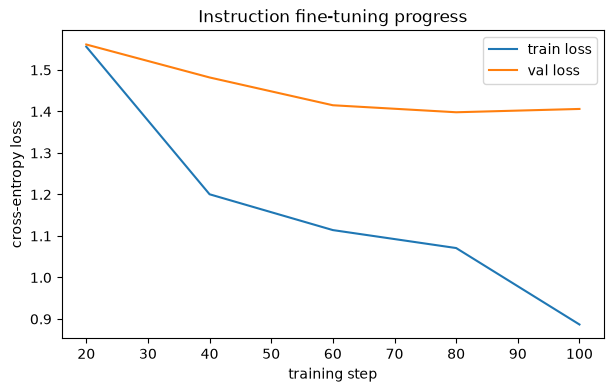

In [12]:
import matplotlib.pyplot as plt

eval_steps = list(range(20, 20 * (len(train_losses) + 1), 20))

plt.figure(figsize=(7, 4))
plt.plot(eval_steps, train_losses, label="train loss")
plt.plot(eval_steps, val_losses, label="val loss")
plt.xlabel("training step")
plt.ylabel("cross-entropy loss")
plt.legend()
plt.title("Instruction fine-tuning progress")
plt.show()

## Evaluating on held-out test instructions

There's no single "accuracy" number for open-ended generation the way there was for spam/ham classification — the right way to judge a response is to actually read it. (In production settings, teams often use additional automated methods too — e.g. having a stronger LLM score responses for quality ["LLM-as-judge"], or standard text-overlap metrics like ROUGE/BLEU — but qualitative reading remains the ground truth. We'll keep it simple here.)

In [13]:
model.eval()

for entry in test_data[:3]:
    prompt = format_input(entry) + "\n\n### Response:\n"
    encoded = torch.tensor(tokenizer.encode(prompt)).unsqueeze(0)
    output_ids = generate(
        model, encoded, max_new_tokens=60, context_size=GPT_CONFIG_124M["context_length"],
        temperature=0.0, eos_id=PAD_TOKEN_ID,
    )
    generated_response = tokenizer.decode(output_ids.squeeze(0).tolist())[len(prompt):].strip()

    print("Instruction:", entry["instruction"])
    if entry.get("input"):
        print("Input:      ", entry["input"])
    print("Reference:  ", entry["output"])
    print("Model:      ", generated_response)
    print("-" * 80)

Instruction: Convert the active sentence to passive: 'The chef cooks the meal every day.'
Reference:   The meal is cooked by the chef every day.
Model:       The meal every day is cooked by the chef.
--------------------------------------------------------------------------------


Instruction: Classify an input string as either a noun or a verb.
Input:       Dance
Reference:   'Dance' can be classified as a verb.
Model:       The noun 'dance' is a form of 'dance-like'.
--------------------------------------------------------------------------------


Instruction: Rewrite the sentence using a metaphor.
Input:       The book is very interesting.
Reference:   The book is a page-turner.
Model:       The book is a metaphor for the book.
--------------------------------------------------------------------------------


Read your own output above honestly: after just one light epoch on under 1,000 examples, expect a mix — some responses land on-topic and roughly correct (e.g. attempting the right sentence structure for a passive-voice conversion), others get the right *format* but wrong *content* (e.g. misclassifying a word, or producing a "metaphor" that isn't really one). That's an accurate, expected outcome, not a bug: the model has clearly learned the *shape* of instruction-following — respond in the template, address the specific task type — from a genuinely tiny amount of fine-tuning data, but real correctness on varied tasks needs the far larger instruction datasets (tens of thousands to millions of examples) and additional training that production instruction-tuned models actually use. The mechanism you built is exactly right; the gap to a polished assistant from here is, once again, mostly a matter of *data scale*, matching the same lesson from notebook 11.

## Recap

- **Instruction fine-tuning** trains a pretrained model on consistently-formatted (instruction, response) pairs using the exact same next-token objective as pretraining — no architecture change needed, since the model is still just predicting tokens.
- Formatting must be **consistent** between training and later use: the model learns to recognize the template itself as the cue to start responding.
- **Loss masking** (`ignore_index=-100`) is essential: we only want the model learning to generate good *responses*, not to "predict" the instructions it's given, and we want padding to not dilute the signal — while still keeping one stop token active so the model learns when a response is finished.
- Because the target behavior change is broad, instruction fine-tuning typically benefits from adapting **more of the network** than narrow classification fine-tuning did.
- Evaluating open-ended generation is inherently more qualitative than classification's clean accuracy metric — reading actual outputs (or more advanced methods like LLM-as-judge scoring) is the real test.

## Where this leaves you

Over these thirteen notebooks, we built a GPT-style language model from the ground up: turning raw text into token IDs, subword tokenization via BPE, sliding-window data batching, token and positional embeddings, self-attention (simplified, then trainable, then causal and multi-headed), full transformer blocks with normalization and residual connections, the complete GPT architecture, text generation and decoding strategies, a real training loop, loading genuine pretrained GPT-2 weights, and finally two styles of fine-tuning. That is, quite literally, the architecture and training recipe underlying real production language models — the difference from there to something like GPT-4 or Claude is overwhelmingly a matter of *scale* (data, parameters, compute) and further alignment techniques (like RLHF or DPO), not a fundamentally different mechanism than what you just built.

From here, natural next directions include: parameter-efficient fine-tuning methods like LoRA (adapting large models with far fewer trainable parameters than we used even in notebook 12), preference-based alignment techniques (RLHF, DPO), quantization and deployment of trained models, and simply scaling everything in this notebook series up with more data and a GPU.